# Survey Basic Analysis (General Questions Only)

This notebook focuses only on the general questions answered by all three groups (`INT`, `PEER`, `EXP`):
- country
- age
- gender
- occupation
- interest in exhibitions (1-5)
- exhibition visits in last 3 years
- self-selected group


## 1) Import libraries


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

# Ensure repository root is on sys.path so `notebooks.*` imports always resolve.
repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks.survey_notebook_utils import load_survey_inputs, setup_notebook_style

setup_notebook_style()


## 2) Load cleaned dataset


In [2]:
# Load the cleaned responses via shared loader and keep only the responses table here.
df, _, _, csv_path, _, _ = load_survey_inputs()

print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape}')


Loaded: ../survey_responses_submitted_cleaned.csv
Shape: (88, 281)


## 3) Validate required columns


In [3]:
# These are the general-question columns used in this notebook.
required_cols = [
    'group_code', 'GENgroup',
    'GENcountry', 'GENcountry[other]',
    'GENage', 'GENgen',
    'GENocc', 'GENocc[comment]',
    'GENintexh', 'GENexhvis',
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

# Show a small preview of relevant columns.
display(df[['group_code', 'GENgroup', 'GENage', 'GENgen', 'GENcountry', 'GENocc', 'GENintexh', 'GENexhvis']].head())


,group_code,GENgroup,GENage,GENgen,GENcountry,GENocc,GENintexh,GENexhvis
0,INT,"I am interested in agricultural knowledge gathering and exhibitions, and agriculture in general.",26-35,Male,Germany,"I'm in post-secondary education (trainee, university, college)",4.0,"Yes, exactly one"
1,INT,"I am interested in agricultural knowledge gathering and exhibitions, and agriculture in general.",36-55,Female,Italy,I'm working,NaN,NaN
2,EXP,I identify as an expert because I impart agricultural knowledge or work in the cultural and exhibition sector.,NaN,NaN,Italy,NaN,NaN,NaN
3,INT,"I am interested in agricultural knowledge gathering and exhibitions, and agriculture in general.",26-35,Female,Other,I'm working,5.0,"Yes, but it was more like a fair (not in a museum or open air in a garden/on a field"
4,INT,"I am interested in agricultural knowledge gathering and exhibitions, and agriculture in general.",26-35,Male,Other,I'm working,5.0,"Yes, but it was more like a fair (not in a museum or open air in a garden/on a field"


## 4) Group sizes and routing check


,group,n_answers
0,INT,37
1,PEER,36
2,EXP,15


Routing consistency table (group_code vs GENgroup):


GENgroup,"I am interested in agricultural knowledge gathering and exhibitions, and agriculture in general.",I am part of the target group of teenagers.,I identify as an expert because I impart agricultural knowledge or work in the cultural and exhibition sector.
group_code,,,
EXP,0,0,15
INT,37,0,0
PEER,0,36,0


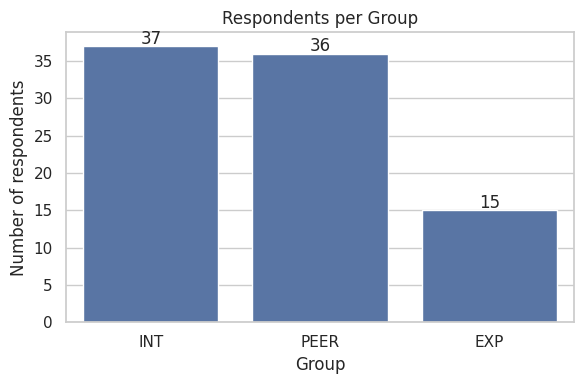

In [4]:
# Count respondents per analysis group.
group_order = ['INT', 'PEER', 'EXP']
group_counts = (
    df['group_code']
    .value_counts()
    .reindex(group_order, fill_value=0)
    .rename_axis('group')
    .reset_index(name='n_answers')
)
display(group_counts)

# Check if the original self-selected group question is consistent with group_code.
routing_table = pd.crosstab(df['group_code'], df['GENgroup'])
print('Routing consistency table (group_code vs GENgroup):')
display(routing_table)

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=group_counts, x='group', y='n_answers', color='#4C72B0')
ax.set_title('Respondents per Group')
ax.set_xlabel('Group')
ax.set_ylabel('Number of respondents')

for i, row in group_counts.iterrows():
    ax.text(i, row['n_answers'] + 0.3, str(int(row['n_answers'])), ha='center')

plt.tight_layout()
plt.show()


## 5) Age distribution by group


Age counts by group:


GENage,13-19,20-25,26-35,36-55,56-70,Above 70,NaN
group_code,,,,,,,
INT,0,9,16,4,7,1,0
PEER,35,0,0,0,0,0,1
EXP,0,3,3,4,4,0,1


Age percentages by group (%):


GENage,13-19,20-25,26-35,36-55,56-70,Above 70,NaN
group_code,,,,,,,
INT,0.0,24.3,43.2,10.8,18.9,2.7,0.0
PEER,97.2,0.0,0.0,0.0,0.0,0.0,2.8
EXP,0.0,20.0,20.0,26.7,26.7,0.0,6.7


<Figure size 1000x500 with 0 Axes>

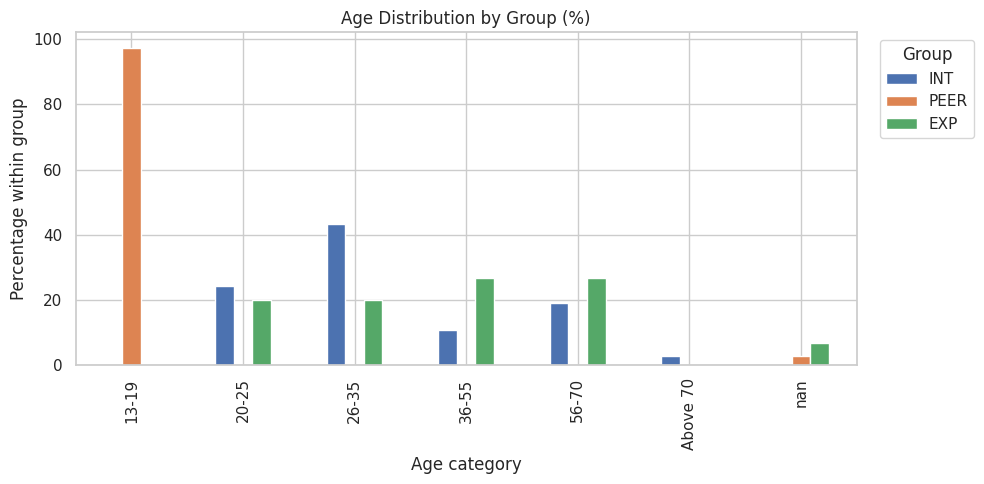

In [5]:
# Build count and percentage tables for age categories.
age_counts = pd.crosstab(df['group_code'], df['GENage'], dropna=False).reindex(group_order, fill_value=0)
age_pct = pd.crosstab(df['group_code'], df['GENage'], normalize='index', dropna=False).reindex(group_order, fill_value=0) * 100

print('Age counts by group:')
display(age_counts)
print('Age percentages by group (%):')
display(age_pct.round(1))

# Plot percentages to compare groups with different sample sizes.
age_plot = age_pct.T
plt.figure(figsize=(10, 5))
age_plot.plot(kind='bar', figsize=(10, 5))
plt.title('Age Distribution by Group (%)')
plt.xlabel('Age category')
plt.ylabel('Percentage within group')
plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 6) Gender distribution by group


Gender counts by group:


GENgen,Female,Male,Missing/Unspecified
group_code,,,
INT,22,15,0
PEER,22,14,0
EXP,12,2,1


Gender percentages by group (%):


GENgen,Female,Male,Missing/Unspecified
group_code,,,
INT,59.5,40.5,0.0
PEER,61.1,38.9,0.0
EXP,80.0,13.3,6.7


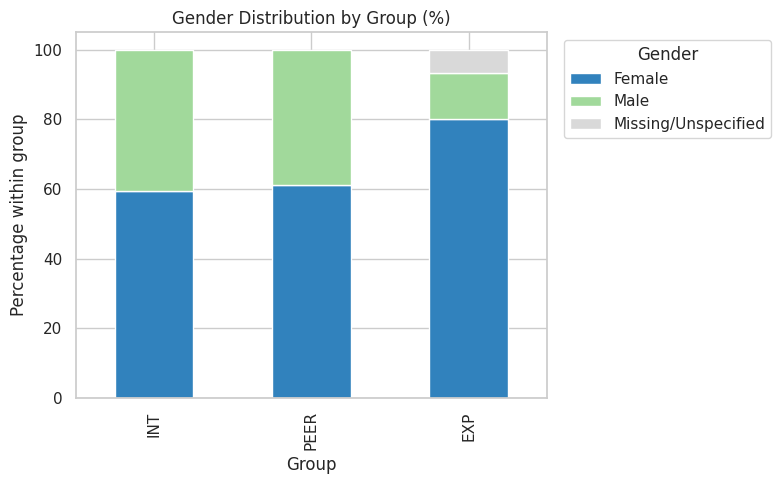

In [6]:
# Clean missing gender values for clearer tables.
gender_clean = df['GENgen'].astype('string').str.strip().fillna('Missing/Unspecified')
gender_clean = gender_clean.replace('', 'Missing/Unspecified')

gender_counts = pd.crosstab(df['group_code'], gender_clean, dropna=False).reindex(group_order, fill_value=0)
gender_pct = pd.crosstab(df['group_code'], gender_clean, normalize='index', dropna=False).reindex(group_order, fill_value=0) * 100

print('Gender counts by group:')
display(gender_counts)
print('Gender percentages by group (%):')
display(gender_pct.round(1))

ax = gender_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab20c')
ax.set_title('Gender Distribution by Group (%)')
ax.set_xlabel('Group')
ax.set_ylabel('Percentage within group')
ax.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 7) Country distribution by group


Country counts by group:


GENcountry,Germany,Italy,Sweden,South Africa,Ireland,Australia,Brasil,Deutschland,Philippines,United States of America
group_code,,,,,,,,,,
INT,27,3,0,1,2,1,0,1,1,1
PEER,35,0,0,0,0,0,1,0,0,0
EXP,9,3,2,1,0,0,0,0,0,0


Country percentages by group (%):


GENcountry,Germany,Italy,Sweden,South Africa,Ireland,Australia,Brasil,Deutschland,Philippines,United States of America
group_code,,,,,,,,,,
INT,73.0,8.1,0.0,2.7,5.4,2.7,0.0,2.7,2.7,2.7
PEER,97.2,0.0,0.0,0.0,0.0,0.0,2.8,0.0,0.0,0.0
EXP,60.0,20.0,13.3,6.7,0.0,0.0,0.0,0.0,0.0,0.0


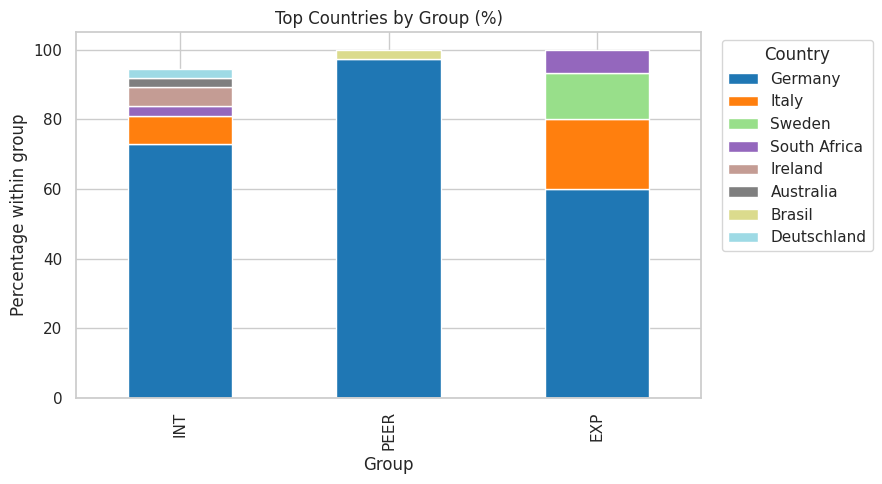

In [7]:
# Replace "Other" with free-text country where available.
country_clean = df['GENcountry'].astype('string').str.strip()
country_other = df['GENcountry[other]'].astype('string').str.strip()

country_final = country_clean.copy()
mask_other = country_final.str.lower().eq('other')
country_final[mask_other] = country_other[mask_other]
country_final = country_final.fillna('Missing/Unspecified').replace('', 'Missing/Unspecified')

country_counts = pd.crosstab(df['group_code'], country_final, dropna=False).reindex(group_order, fill_value=0)
country_pct = pd.crosstab(df['group_code'], country_final, normalize='index', dropna=False).reindex(group_order, fill_value=0) * 100

# Sort columns by total frequency so the most common countries come first.
country_order = country_counts.sum(axis=0).sort_values(ascending=False).index
country_counts = country_counts[country_order]
country_pct = country_pct[country_order]

print('Country counts by group:')
display(country_counts)
print('Country percentages by group (%):')
display(country_pct.round(1))

# Show only top 8 countries in a compact stacked chart.
top_countries = country_counts.sum(axis=0).head(8).index
country_pct_top = country_pct[top_countries]

ax = country_pct_top.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='tab20')
ax.set_title('Top Countries by Group (%)')
ax.set_xlabel('Group')
ax.set_ylabel('Percentage within group')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 8) Occupation distribution by group


Occupation counts by group:


GENocc,I'm a student,I'm working,"I'm in post-secondary education (trainee, university, college)",I'm unemployed,I'm not working anymore (e.g. retired),Missing/Unspecified,Schülerin
group_code,,,,,,,
INT,10,18,6,2,1,0,0
PEER,32,1,1,1,0,0,1
EXP,3,8,2,1,0,1,0


Occupation percentages by group (%):


GENocc,I'm a student,I'm working,"I'm in post-secondary education (trainee, university, college)",I'm unemployed,I'm not working anymore (e.g. retired),Missing/Unspecified,Schülerin
group_code,,,,,,,
INT,27.0,48.6,16.2,5.4,2.7,0.0,0.0
PEER,88.9,2.8,2.8,2.8,0.0,0.0,2.8
EXP,20.0,53.3,13.3,6.7,0.0,6.7,0.0


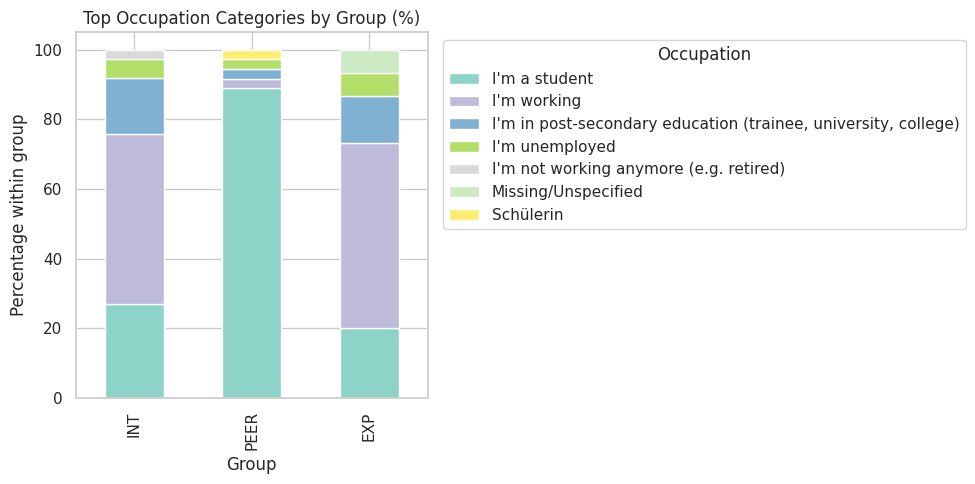

In [8]:
# Use the main occupation answer and fallback to comment if needed.
occ_main = df['GENocc'].astype('string').str.strip()
occ_comment = df['GENocc[comment]'].astype('string').str.strip()

occ_final = occ_main.copy()
mask_empty = occ_final.isna() | occ_final.eq('')
occ_final[mask_empty] = occ_comment[mask_empty]
occ_final = occ_final.fillna('Missing/Unspecified').replace('', 'Missing/Unspecified')

occ_counts = pd.crosstab(df['group_code'], occ_final, dropna=False).reindex(group_order, fill_value=0)
occ_pct = pd.crosstab(df['group_code'], occ_final, normalize='index', dropna=False).reindex(group_order, fill_value=0) * 100

# Keep display readable by focusing on most common categories.
occ_order = occ_counts.sum(axis=0).sort_values(ascending=False).index
occ_counts = occ_counts[occ_order]
occ_pct = occ_pct[occ_order]

print('Occupation counts by group:')
display(occ_counts)
print('Occupation percentages by group (%):')
display(occ_pct.round(1))

top_occ = occ_counts.sum(axis=0).head(8).index
ax = occ_pct[top_occ].plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set3')
ax.set_title('Top Occupation Categories by Group (%)')
ax.set_xlabel('Group')
ax.set_ylabel('Percentage within group')
ax.legend(title='Occupation', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 9) Interest in exhibitions (1-5) by group


Interest counts by group (1-5):


interest,1,2,3,4,5
group_code,,,,,
INT,2,0,1,12,18
PEER,2,3,5,15,8
EXP,0,0,1,2,8


Interest percentages by group (%):


interest,1,2,3,4,5
group_code,,,,,
INT,6.1,0.0,3.0,36.4,54.5
PEER,6.1,9.1,15.2,45.5,24.2
EXP,0.0,0.0,9.1,18.2,72.7


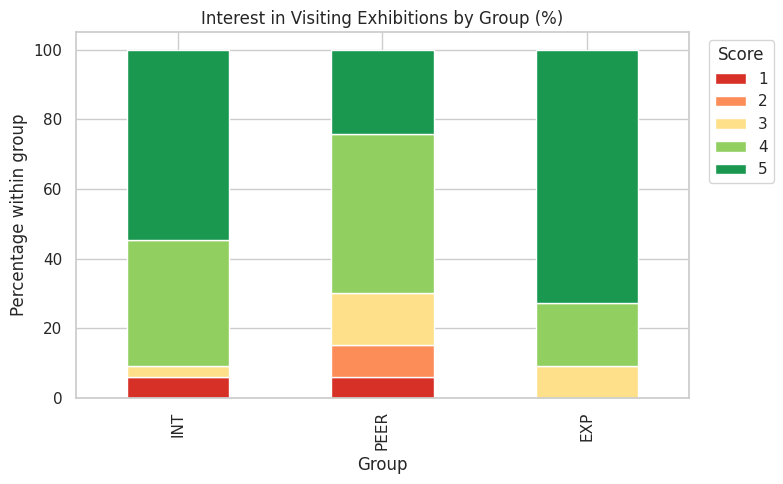

In [9]:
# Convert to numeric and keep only valid 1..5 values.
interest = pd.to_numeric(df['GENintexh'], errors='coerce')
interest_df = df[['group_code']].copy()
interest_df['interest'] = interest
interest_df = interest_df[interest_df['interest'].between(1, 5)]
interest_df['interest'] = interest_df['interest'].astype(int)

interest_counts = pd.crosstab(interest_df['group_code'], interest_df['interest']).reindex(group_order, fill_value=0)
interest_counts = interest_counts.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
interest_pct = interest_counts.div(interest_counts.sum(axis=1), axis=0) * 100

print('Interest counts by group (1-5):')
display(interest_counts)
print('Interest percentages by group (%):')
display(interest_pct.round(1))

ax = interest_pct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#D73027', '#FC8D59', '#FEE08B', '#91CF60', '#1A9850'])
ax.set_title('Interest in Visiting Exhibitions by Group (%)')
ax.set_xlabel('Group')
ax.set_ylabel('Percentage within group')
ax.legend(title='Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 10) Exhibition visits in last 3 years by group


Exhibition visit counts by group:


GENexhvis,"Yes, but it was more like a fair (not in a museum or open air in a garden/on a field","No, not within the last three years, but before yes","Yes, more then one","No, I've never been but I'd like to go","Yes, exactly one",Missing/Unspecified,"No, I'm not interested"
group_code,,,,,,,
INT,8,10,9,6,3,1,0
PEER,7,6,2,7,5,4,5
EXP,4,2,6,1,1,1,0


Exhibition visit percentages by group (%):


GENexhvis,"Yes, but it was more like a fair (not in a museum or open air in a garden/on a field","No, not within the last three years, but before yes","Yes, more then one","No, I've never been but I'd like to go","Yes, exactly one",Missing/Unspecified,"No, I'm not interested"
group_code,,,,,,,
INT,21.6,27.0,24.3,16.2,8.1,2.7,0.0
PEER,19.4,16.7,5.6,19.4,13.9,11.1,13.9
EXP,26.7,13.3,40.0,6.7,6.7,6.7,0.0


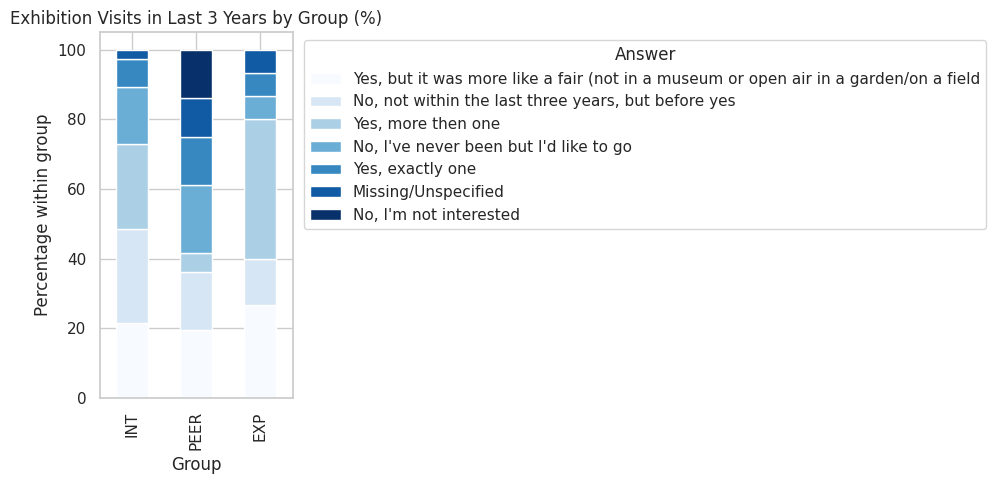

In [10]:
# Standardize empty values and compare distributions by group.
visit_clean = df['GENexhvis'].astype('string').str.strip().fillna('Missing/Unspecified')
visit_clean = visit_clean.replace('', 'Missing/Unspecified')

visit_counts = pd.crosstab(df['group_code'], visit_clean, dropna=False).reindex(group_order, fill_value=0)
visit_pct = pd.crosstab(df['group_code'], visit_clean, normalize='index', dropna=False).reindex(group_order, fill_value=0) * 100

visit_order = visit_counts.sum(axis=0).sort_values(ascending=False).index
visit_counts = visit_counts[visit_order]
visit_pct = visit_pct[visit_order]

print('Exhibition visit counts by group:')
display(visit_counts)
print('Exhibition visit percentages by group (%):')
display(visit_pct.round(1))

ax = visit_pct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Blues')
ax.set_title('Exhibition Visits in Last 3 Years by Group (%)')
ax.set_xlabel('Group')
ax.set_ylabel('Percentage within group')
ax.legend(title='Answer', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 11) Quick summary table (all general variables)


In [11]:
# Compact completeness table: how many non-missing answers we have per general variable and group.
vars_general = ['GENcountry', 'GENage', 'GENgen', 'GENocc', 'GENintexh', 'GENexhvis', 'GENgroup']

summary_rows = []
for g in group_order:
    dfg = df[df['group_code'] == g]
    for v in vars_general:
        non_missing = dfg[v].astype('string').str.strip().replace('nan', '').replace('<NA>', '').ne('').sum()
        summary_rows.append({
            'group': g,
            'variable': v,
            'n_non_missing': int(non_missing),
            'n_total_group': int(len(dfg)),
            'pct_non_missing': round((non_missing / len(dfg) * 100) if len(dfg) > 0 else 0, 1),
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,group,variable,n_non_missing,n_total_group,pct_non_missing
0,INT,GENcountry,37,37,100.0
1,INT,GENage,37,37,100.0
2,INT,GENgen,37,37,100.0
3,INT,GENocc,37,37,100.0
4,INT,GENintexh,33,37,89.2
5,INT,GENexhvis,36,37,97.3
6,INT,GENgroup,37,37,100.0
7,PEER,GENcountry,36,36,100.0
8,PEER,GENage,35,36,97.2
9,PEER,GENgen,36,36,100.0


## 12) Final remarks / tips (all groups)

This section shows the open final feedback fields for all groups (`INT`, `PEER`, `EXP`).


In [12]:
# Show final feedback fields from all groups in one place.
feedback_cols = ['id', 'group_code', 'ENDraise', 'ENDfeed']
missing_feedback_cols = [c for c in feedback_cols if c not in df.columns]
if missing_feedback_cols:
    raise ValueError(f'Missing feedback columns: {missing_feedback_cols}')

# Helper: normalize text, remove empty placeholders, keep real answers.
def clean_text(series: pd.Series) -> pd.Series:
    s = series.astype('string').str.strip()
    s = s.replace({'': pd.NA, 'nan': pd.NA, '<NA>': pd.NA})
    return s

feedback_df = df[feedback_cols].copy()
feedback_df['ENDraise_clean'] = clean_text(feedback_df['ENDraise'])
feedback_df['ENDfeed_clean'] = clean_text(feedback_df['ENDfeed'])

# Quick counts: how many respondents gave a non-empty answer per group.
feedback_counts = (
    feedback_df.groupby('group_code')
    .agg(
        n_group=('id', 'count'),
        n_ENDraise=('ENDraise_clean', lambda x: x.notna().sum()),
        n_ENDfeed=('ENDfeed_clean', lambda x: x.notna().sum()),
    )
    .reindex(group_order)
)
feedback_counts['pct_ENDraise'] = (feedback_counts['n_ENDraise'] / feedback_counts['n_group'] * 100).round(1)
feedback_counts['pct_ENDfeed'] = (feedback_counts['n_ENDfeed'] / feedback_counts['n_group'] * 100).round(1)

print('Final feedback coverage by group:')
display(feedback_counts)

# Table 1: questionnaire raised interest (ENDraise) - show all non-empty answers.
endraise_table = (
    feedback_df.loc[feedback_df['ENDraise_clean'].notna(), ['id', 'group_code', 'ENDraise_clean']]
    .rename(columns={'ENDraise_clean': 'ENDraise'})
    .sort_values(['group_code', 'id'])
)
print(f"All non-empty ENDraise answers (n={len(endraise_table)}):")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(endraise_table)

# Table 2: final comments/tips (ENDfeed) - show all non-empty answers in full text.
endfeed_table = (
    feedback_df.loc[feedback_df['ENDfeed_clean'].notna(), ['id', 'group_code', 'ENDfeed_clean']]
    .rename(columns={'ENDfeed_clean': 'ENDfeed'})
    .sort_values(['group_code', 'id'])
)
print(f"All non-empty ENDfeed answers (n={len(endfeed_table)}):")
endfeed_styled = (
    endfeed_table.style
    .set_properties(subset=['ENDfeed'], **{'white-space': 'pre-wrap', 'text-align': 'left'})
    .set_table_styles([
        {'selector': 'table', 'props': [('table-layout', 'fixed'), ('width', '100%')]},
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('vertical-align', 'top')]},
    ])
)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(endfeed_styled)


Final feedback coverage by group:


,n_group,n_ENDraise,n_ENDfeed,pct_ENDraise,pct_ENDfeed
group_code,,,,,
INT,37,36,8,97.3,21.6
PEER,36,35,6,97.2,16.7
EXP,15,13,5,86.7,33.3


All non-empty ENDraise answers (n=84):


,id,group_code,ENDraise
25,61,EXP,Yes
26,62,EXP,Yes
27,65,EXP,My interest remained the same
29,67,EXP,My interest remained the same
33,76,EXP,In some cases
34,77,EXP,My interest remained the same
38,83,EXP,Yes
41,87,EXP,In some cases
44,91,EXP,My interest remained the same
45,92,EXP,My interest remained the same


All non-empty ENDfeed answers (n=19):


,id,group_code,ENDfeed
25,61,EXP,"Teenagers are a tough demographic but important as they are starting to develop their own ideas and concepts of the world. However, they are quick to decide if a topic is interesting to them or not - I think my answers are based on a general idea of what may first capture a teens interest but some teens once interested may go above and beyond. Otherwise I think a lot of teens who have mild interest or none quickly move on."
29,67,EXP,"Meiner Erfahrung nach ist das Wort ""Pestizid"""" bei den Landwirten und Landwirtinnen ein no go und triggert viele Personen, weil die Pflanzen mit den Mitteln geschützt und nicht vergiftet werden. Daher hat der Begriff """"Pflanzenschutzmittel"""" eine viel höhere Akzeptanz in der Praxis. In der Gesellschaft und Medien wird der Landwirt/die Landwirtin häufig als """"Schädigende Person"""" dargestellt, was viele Landwirtschaftende belastet."
34,77,EXP,"In der letzten Frage habe ich bereits angemerkt, dass die Altersspanne, die angesetzt wurde, für mich so nicht funktioniert. Angebote gerichtet an ein 13jähriges Kind (Pubertät) müssen anders aufgebaut sein, als an junge Erwachsene. Wenn wirklich etwas bewegt werden will, muss die Zielgruppe genauer betrachtet werden. Ausstellungen werden oft konzipiert nach bester und umfänglichster Wissensvermittlung für ein breites Publikum und Alter. Daher ist es für mich eher sinnvoll in der Altersgruppe bis 17 oder 18 Jahren nicht auf Ausstellungen zu setzen, sondern eher auf Spiele, Workshops u.ä. um gezieltes Wissen zu vermitteln. Ausstellungen nur als Wanderfromate, die Übersichten über Themenfelder bieten, um Workshops u.ä. vorzubereiten. Vor allem wenn man auch (und das sollte das formalige Ziel sein) auch bildungsarme oder benachteiligte Kinder und Jugendliche erreichen will."
41,87,EXP,"Education is key, and this field should be more part of it. I like what you are doing"
44,91,EXP,.
0,18,INT,"Er hat mein Bewusstsein für die viele Arbeit geschärft, die sicherlich in der Konzeption einer Ausstellung (mit Ansprüchen) steckt."
16,41,INT,"Die Teenager sind kaum auf gleiche Weise an diesen Fragen interessiert und durch soziales Umfeld und Vorbildung unterschiedlich geprägt, so dass eine allgemeine Beurteilung schwierig ist. Grundsätzlich sollte aber durch Angebote in Schulen und anderen Bildungsstätten bei allen das Interesse an diesen großteils existenziellen Fragen geweckt werden."
49,96,INT,"In the age of ""IPad Kids"""" and how integrated technology is in our everyday lives, I think building excitement around this program could look like a happy mix between social media presence and school/after-school/community center collaborations where kids are brought into the space via an organized visit (such as a field trip). But I think a lot of parents would like this for their kids as a weekend activity. I have some relatives that love taking their son to interactive kids exhibits as a way of doing activities outside of screen time :)"
57,107,INT,No
71,128,INT,"man kann leider nicht zurückscrollen, wenn man etwas ändern möchte"
